# **Image-to-Poem Generation Using Deep Generative Models**
## CSC 594: Topics in AI

### Student Correspondences:

1. Neha Anusooya Thimmarayi - nanusooy@depaul.edu
2. Rohan Shankar Patil - rpatil5@depaul.edu

#### Project Description:

This project explores the use of deep generative models to generate creative, emotionally resonant poetry from visual inputs. The core objective is to develop a machine learning system that accepts an image and generates a corresponding poem that captures the image’s mood, theme, or aesthetic, rather than providing literal descriptions.

----------------

### 1. Introduction to Libraries

This project utilizes a range of libraries for data processing, deep learning, and image-text modeling:

1. **NumPy** and **Pandas** are used for efficient numerical operations and structured data manipulation.
2. **PyTorch** is the core deep learning framework used to build and train models.
3. **Torchvision** provides pre-trained models and image transformation utilities.
4. **Transformers** (by Hugging Face) loads the pre-trained CLIP model for visual feature extraction.
5. **Pillow (PIL)** and **Requests** help load and process image data from URLs.
6. **tqdm** is used for progress bars during image processing and dataset iteration.

#### 1.1 Importing Required Libraries

In [1]:
import os
import json
import random
import pandas as pd
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import transforms
from transformers import CLIPProcessor, CLIPModel
from torchvision.models import resnet18
from tqdm import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt


In [2]:
# Check if a GPU is available and print the result (useful for performance monitoring)
if torch.cuda.is_available():
    print("GPU is available")
else:
    print("GPU is not available")

GPU is available


-----

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Access dataset
!ls /content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI

Mounted at /content/drive
checkpoints  data  multim_poem.json


### 2. Model Design and Implementation

This section describes the overall model pipeline, including how input data is preprocessed, how image features are extracted and projected into a textual embedding space, and how the resulting representations are used for poem generation using GPT-2.



#### 2.1 Data Preprocessing and Dataset Preparation

We begin by filtering and cleaning a multimodal dataset consisting of images and their corresponding poems. The dataset is parsed from JSON, cleaned to remove empty entries, and saved in structured CSV and JSON formats. Images are downloaded using their URLs, and only those with valid image-poem pairs are retained. A total of 899 usable pairs were selected for training.



In [4]:
# Load the raw multimodal poem dataset from JSON and inspect its structure
dataset_path = '/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/multim_poem.json'

with open(dataset_path, 'r') as f:
    data = json.load(f)

print(f"Total entries in dataset: {len(data)}")

# Display a sample entry to understand the data format
print("Example entry:")
print(json.dumps(data[0], indent=2))

Total entries in dataset: 8292
Example entry:
{
  "poem": "what is lovely never dies\nbut passes into other loveliness\nstar-dust or sea-foam flower or winged air",
  "image_url": "https://farm2.staticflickr.com/1086/1002051357_0e9162423e.jpg",
  "id": 0
}


In [5]:
# Filter out entries with missing or empty poems or image URLs
cleaned_data = []

for item in data:
    poem = item.get("poem")
    url = item.get("img") or item.get("image_url")

    if poem and url and poem.strip():
        cleaned_data.append({
            "image_url": url,
            "poem": poem.strip()
        })

print(f"Cleaned dataset size: {len(cleaned_data)} entries")

# Convert the cleaned data to a DataFrame for further processing
df = pd.DataFrame(cleaned_data)
df.head()

Cleaned dataset size: 8292 entries


,image_url,poem
0,https://farm2.staticflickr.com/1086/1002051357...,what is lovely never dies\nbut passes into oth...
1,https://farm8.staticflickr.com/7434/1002469112...,sods on the dugout begin to be fledged\nwith f...
2,https://farm1.staticflickr.com/19/100255672_97...,one must have the mind of winter\nto regard th...
3,https://farm2.staticflickr.com/1034/1002997433...,to put meaning in one's life may end in madnes...
4,https://farm4.staticflickr.com/3741/1004000893...,of living pained branches\nmy garden's braided...


In [6]:
# Save the cleaned dataset in both CSV and JSON formats for future use
os.makedirs("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed", exist_ok=True)
df.to_csv("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed/cleaned_poems.csv", index=False)
df.to_json("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed/cleaned_poems.json", orient="records", indent=2)

print("Cleaned dataset saved.")

Cleaned dataset saved.


###  Load Available Images and Filter Dataset

This cell loads all `.jpg` image files that were previously downloaded and stored in the `image_dir`. It uses the image filenames (e.g., `0.jpg`, `1.jpg`, ...) to identify which rows in the original `df` are valid. It then creates a filtered version of the dataset (`valid_df`) that only includes entries corresponding to available image files. Finally, it saves this filtered DataFrame to `filtered_poem_data.csv` for future use.

In [7]:
image_dir = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/images"
os.makedirs(image_dir, exist_ok=True)

available_image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

available_indices = sorted([int(f.split('.')[0]) for f in available_image_files])

print(f"Found {len(available_indices)} image files in '{image_dir}'")

valid_df = df.loc[available_indices].reset_index(drop=True)

valid_df['image_filename'] = valid_df.index.astype(str) + '.jpg'

print(f"Final valid_df size: {len(valid_df)} entries")
print("Columns in valid_df:", valid_df.columns)
print("First few rows of valid_df:")
print(valid_df.head())

processed_dir = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed"
os.makedirs(processed_dir, exist_ok=True)
valid_df.to_csv(os.path.join(processed_dir, "filtered_poem_data.csv"), index=False)



Found 7415 image files in '/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/images'
Final valid_df size: 7415 entries
Columns in valid_df: Index(['image_url', 'poem', 'image_filename'], dtype='object')
First few rows of valid_df:
                                           image_url  \
0  https://farm2.staticflickr.com/1086/1002051357...   
1  https://farm8.staticflickr.com/7434/1002469112...   
2  https://farm1.staticflickr.com/19/100255672_97...   
3  https://farm2.staticflickr.com/1034/1002997433...   
4  https://farm4.staticflickr.com/3741/1004000893...   

                                                poem image_filename  
0  what is lovely never dies\nbut passes into oth...          0.jpg  
1  sods on the dugout begin to be fledged\nwith f...          1.jpg  
2  one must have the mind of winter\nto regard th...          2.jpg  
3  to put meaning in one's life may end in madnes...          3.jpg  
4  of living pained branches\nmy garden's braided...          4.jpg  


In [8]:
valid_df = pd.read_csv("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed/filtered_poem_data.csv")
print("Columns in valid_df after loading:", valid_df.columns)
print(valid_df.head())


Columns in valid_df after loading: Index(['image_url', 'poem', 'image_filename'], dtype='object')
                                           image_url  \
0  https://farm2.staticflickr.com/1086/1002051357...   
1  https://farm8.staticflickr.com/7434/1002469112...   
2  https://farm1.staticflickr.com/19/100255672_97...   
3  https://farm2.staticflickr.com/1034/1002997433...   
4  https://farm4.staticflickr.com/3741/1004000893...   

                                                poem image_filename  
0  what is lovely never dies\nbut passes into oth...          0.jpg  
1  sods on the dugout begin to be fledged\nwith f...          1.jpg  
2  one must have the mind of winter\nto regard th...          2.jpg  
3  to put meaning in one's life may end in madnes...          3.jpg  
4  of living pained branches\nmy garden's braided...          4.jpg  


#### 2.2 Designing the Image Encoder

To explore how different visual representations affect text generation, we implemented two image encoders:

- **CLIP** (Contrastive Language–Image Pre-training): A vision-language model pre-trained on 400 million image-text pairs. We used the vision tower of the `openai/clip-vit-base-patch32` variant to extract 512-dimensional image embeddings. These embeddings are inherently normalized by the model.

- **ResNet18**: A convolutional neural network pre-trained on ImageNet, used to extract 512-dimensional embeddings from images. We removed its final classification layer and normalized the output feature vectors.




#### 2.2.1  Designing the Image Encoder (CLIP - Contrastive Language-Image Pre-training)

We used the `openai/clip-vit-base-patch32` model from Hugging Face Transformers to extract image embeddings. Each image is passed through the CLIP image processor to perform resizing, normalization, and tensor conversion. The processed image is then fed into the model's vision tower to obtain a 512-dimensional embedding.

In [9]:
# Load pre-trained CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Ensure the model is on the same device as your PyTorch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [10]:
def extract_image_features(image_path):
    """
    Extract visual features from an image using CLIP.

    Args:
        image_path (str): Path to the image file.

    Returns:
        torch.Tensor: Feature vector of shape (1, 512) representing the image.
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt").to(device)

    # Extract features from the model
    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)

    # Normalize features (CLIP features are typically L2-normalized)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    return image_features

In [11]:
# Test the feature extraction function
def test_image_feature_extraction():
    # Use a sample image from your dataset (e.g., the first valid image)
    sample_image_path = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/images/0.jpg"
    if os.path.exists(sample_image_path):
        features = extract_image_features(sample_image_path)
        print(f"Extracted feature shape: {features.shape}")  # Expected: torch.Size([1, 512])
        print(f"Feature norm: {features.norm(dim=-1).item():.4f}")  # Should be close to 1.0 due to normalization
    else:
        print("Sample image not found. Please ensure images are downloaded.")

In [12]:
# Run the test
test_image_feature_extraction()

Extracted feature shape: torch.Size([1, 512])
Feature norm: 1.0000


In [13]:
# Extract features for the dataset (optional: process a subset for testing)
def process_dataset_features(df, image_dir, output_path="/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/Feature_Extraction/image_features.pt"):
    features_list = []
    for index, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(image_dir, row["image_filename"])
        if os.path.exists(img_path):
            features = extract_image_features(img_path)
            features_list.append(features.cpu())  # Move to CPU to save GPU memory
    torch.save(torch.cat(features_list, dim=0), output_path)
    print(f"Saved {len(features_list)} image features to {output_path}")

In [14]:
# Ensure valid_df is defined by reloading or recreating it if necessary
if 'valid_df' not in globals():
    # Load the filtered dataset if it exists, or recreate it
    filtered_csv_path = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed/filtered_poem_data.csv"
    if os.path.exists(filtered_csv_path):
        valid_df = pd.read_csv(filtered_csv_path)
        print(f"Loaded valid_df from {filtered_csv_path} with {len(valid_df)} entries")
    else:
        print("Filtered dataset not found. Recreating from raw data...")
        valid_indices = [i for i in range(8292) if os.path.exists(f"/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/images/{i}.jpg")]
        sample_df = pd.DataFrame(data).sample(n=8292, random_state=42).reset_index(drop=True)
        valid_df = sample_df.loc[valid_indices].reset_index(drop=True)
        valid_df.to_csv(filtered_csv_path, index=False)
        print(f"Recreated valid_df with {len(valid_df)} entries and saved to {filtered_csv_path}")

# Process a subset of the dataset for testing
subset_df = valid_df.head(8292)
process_dataset_features(subset_df, "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/images")

100%|██████████| 7415/7415 [05:17<00:00, 23.38it/s]


Saved 7415 image features to /content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/Feature_Extraction/image_features.pt


In [15]:
loaded_features = torch.load("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/Feature_Extraction/image_features.pt")
print(loaded_features.shape)  # Should be torch.Size([7415, 512])

torch.Size([7415, 512])


#### 2.2.2 Designing the Image Encoder (ResNet18 - Convolutional Visual Features)

ResNet18 was loaded using torchvision.models, and its final classification layer was removed. Images were preprocessed to match the model’s expected input format (224×224 resolution, normalized using ImageNet mean and std), and the 512-d feature vector was extracted from the penultimate layer.

In [16]:
#Load ResNet18 model without final classification layer
resnet_model = resnet18(pretrained=True)
resnet_model = torch.nn.Sequential(*list(resnet_model.children())[:-1])
resnet_model.eval().to(device)

#Define standard image preprocessing steps for ResNet input
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Extract and return a single 512-d ResNet feature vector from a given image
def extract_resnet_features(image_path):
    image = Image.open(image_path).convert("RGB")
    image = resnet_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = resnet_model(image).squeeze()
    return features



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


In [17]:
# Test the first ResNet feature before batch processing
sample_path = os.path.join(image_dir, valid_df.loc[0, "image_filename"])
sample_feature = extract_resnet_features(sample_path)

print("Sample feature shape:", sample_feature.shape)
print("Norm before normalization:", torch.norm(sample_feature).item())
print("First 10 values:", sample_feature[:10])


Sample feature shape: torch.Size([512])
Norm before normalization: 31.31451988220215
First 10 values: tensor([1.8182, 0.4423, 1.9073, 3.1980, 1.6768, 0.2755, 0.2358, 1.7057, 2.0730,
        0.5250], device='cuda:0')


In [18]:
#Extract and normalize ResNet features for all images in the dataset
def process_resnet_dataset(df, image_dir, output_path):
    features_list = []
    for index, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(image_dir, row["image_filename"])
        if os.path.exists(img_path):
            features = extract_resnet_features(img_path)
            features = features / features.norm()  # L2-normalize
            features_list.append(features.cpu())

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    torch.save(torch.stack(features_list), output_path)
    print(f"Saved {len(features_list)} normalized ResNet features to {output_path}")


In [19]:
# Process the full dataset and save all normalized ResNet18 features to disk
resnet_output_path = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/features/resnet_features.pt"
process_resnet_dataset(valid_df, image_dir, resnet_output_path)


100%|██████████| 7415/7415 [01:08<00:00, 107.58it/s]


Saved 7415 normalized ResNet features to /content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/features/resnet_features.pt


In [20]:
# Load the saved ResNet feature vectors and verify their shape and normalization
resnet_output_path = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/features/resnet_features.pt"
resnet_features = torch.load(resnet_output_path)
print(f"Loaded ResNet features shape: {resnet_features.shape}")
print("Norm sample:", resnet_features[0].norm().item())

Loaded ResNet features shape: torch.Size([7415, 512])
Norm sample: 1.0


#### 2.3 Building the Dense Projection Network

To bridge the gap between the 512-d image features and GPT-2’s 768-d input space, we use a shared projection network for both encoders. This network transforms the single 512-d vector into a sequence of 10 GPT-2-compatible prefix tokens.

#### 2.3.1 Projection for CLIP Features

### Define CLIP Feature Projector

This cell defines a `ImageToTextProjection` PyTorch module that maps extracted CLIP image features (dimension = 512) into a sequence of embeddings compatible with GPT-2 (dimension = 768). The output shape is `(batch_size, prefix_length, 768)`, which serves as a learned prefix for GPT-2 during conditional generation. A small dropout is applied for regularization.

In [21]:
class ImageToTextProjection(nn.Module):
    def __init__(self, input_dim=512, gpt2_emb_dim=768, prefix_length=10):
        super(ImageToTextProjection, self).__init__()
        self.prefix_length = prefix_length
        self.gpt2_emb_dim = gpt2_emb_dim
        self.projector = nn.Sequential(
            nn.Linear(input_dim, gpt2_emb_dim * prefix_length),  # Maps 512 to 7680 (10*768)
            nn.Tanh(),  # Non-linear activation to capture complex mappings
            nn.Dropout(0.2)
        )

    def forward(self, x):
        out = self.projector(x)  # Shape: (batch_size, 7680)
        return out.view(-1, self.prefix_length, self.gpt2_emb_dim)  # Shape: (batch_size, 10, 768)

# Initialize the projection model
clip_projector = ImageToTextProjection(input_dim=512, gpt2_emb_dim=768, prefix_length=10)

In [22]:
# Load saved CLIP features
clip_features = torch.load(r"/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/Feature_Extraction/image_features.pt")

# Project features
projected_clip_features = clip_projector(clip_features)
print(f"Projected CLIP feature shape: {projected_clip_features.shape}")  # ([7415, 10, 768])

Projected CLIP feature shape: torch.Size([7415, 10, 768])


In [23]:
# Save projected features
torch.save(projected_clip_features, r"/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/Feature_Extraction/clip_projected_prefix.pt")
print("Projected CLIP prefixes saved.")

Projected CLIP prefixes saved.


#### 2.3.2 Projection for ResNet18 Features

### Define Image Feature to GPT-2 Embedding Projector

This cell implements a projection network that transforms 512-dimensional image feature vectors (e.g., from CLIP or ResNet) into a sequence of prefix embeddings compatible with GPT-2. The projected output has shape `(batch_size, prefix_length, 768)` and can be prepended to GPT-2’s input embeddings to guide conditional generation. The projection includes a linear transformation, `Tanh` activation, and `Dropout` for regularization.

In [24]:
# Define a projection network to map 512-d image features to a sequence of GPT-2-compatible prefix embeddings
class ImageToTextProjection(nn.Module):
    def __init__(self, input_dim=512, gpt2_emb_dim=768, prefix_length=10):
        super(ImageToTextProjection, self).__init__()
        self.prefix_length = prefix_length
        self.gpt2_emb_dim = gpt2_emb_dim
        self.projector = nn.Sequential(
            nn.Linear(input_dim, gpt2_emb_dim * prefix_length),
            nn.Tanh(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        out = self.projector(x)
        return out.view(-1, self.prefix_length, self.gpt2_emb_dim)

# Initialize the projection model
projector = ImageToTextProjection(input_dim=512, gpt2_emb_dim=768, prefix_length=10)

In [25]:
# Project all ResNet features into GPT-2 embedding space as prefix tokens
projected_all = projector(resnet_features)
print("Projected shape:", projected_all.shape) #Expected: (7415, 10, 768)

Projected shape: torch.Size([7415, 10, 768])


In [26]:
# Save the projected prefix embeddings to disk for use in GPT-2 conditioning
torch.save(projected_all, "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/features/resnet_projected_prefix.pt")
print("Projected prefixes saved.")

Projected prefixes saved.


In [27]:
# Load the filtered dataset and iterate over all image-poem pairs
valid_df = pd.read_csv("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed/filtered_poem_data.csv")
assert len(valid_df) == 7415

# Iterate through image-poem pairs: for each projected prefix, retrieve the corresponding poem text
for i in range(len(valid_df)):
    image_prefix = projected_all[i]  # (10, 768)
    poem = valid_df.loc[i, "poem"]

print(image_prefix.shape)

torch.Size([10, 768])


#### 2.4 Configuring the GPT-2 Decoder

### GPT-2 (Generative Pretrained Transformer 2)

**GPT-2**, developed by OpenAI, is a large-scale autoregressive language model based on the Transformer architecture. It is trained to predict the next token in a sequence, making it capable of generating coherent and contextually relevant text.

**Key features:**
- Uses a Transformer-based decoder architecture with self-attention
- Trained on a massive corpus of internet text (unsupervised)
- Learns powerful representations of language without task-specific labels
- Can be fine-tuned for downstream tasks like text generation, summarization, and more

**In this project:**
- We use GPT-2 to generate poems from image features.
- Image features (from ResNet and CLIP) are projected into GPT-2’s embedding space and used as a prefix.
- GPT-2 is fine-tuned on our dataset of image-poem pairs to generate human-like poetry based on visual input.

#### Load GPT-2 Model and Tokenizer

In this step, we load the pre-trained GPT-2 language model along with its tokenizer from Hugging Face. We set the pad token to the end-of-sequence token (`<|endoftext|>`) since GPT-2 does not have a dedicated pad token. The model is moved to GPU if available.

In [28]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load GPT-2 and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # For padding
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [29]:
# Load valid poems
df_path = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/processed/filtered_poem_data.csv"
valid_df = pd.read_csv(df_path)
poems = valid_df["poem"].tolist()

In [30]:
# Tokenize poems
encoding = tokenizer(poems, return_tensors="pt", padding=True, truncation=True, max_length=50)
input_ids = encoding.input_ids.to(device)  # (7415, seq_len)
attention_mask = encoding.attention_mask.to(device)
print(f"Tokenized poems shape: {input_ids.shape}")

Tokenized poems shape: torch.Size([7415, 50])


In [31]:
# Get GPT-2 token embeddings
token_embeddings = gpt2.transformer.wte(input_ids)  # (7415, seq_len, 768)
print(f"GPT-2 token embeddings shape: {token_embeddings.shape}")

GPT-2 token embeddings shape: torch.Size([7415, 50, 768])


In [32]:
# Load ResNet and CLIP projected prefixes
resnet_prefix = torch.load("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/features/resnet_projected_prefix.pt").to(device)  # (898, 10, 768)
clip_prefix = torch.load("/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/data/Feature_Extraction/clip_projected_prefix.pt").to(device)  # (898, 10, 768)


#### Combine ResNet and CLIP Prefixes with Token Embeddings

In this step, we concatenate the projected image features from both ResNet and CLIP models to form a unified prefix representation. This combined prefix (shape: `[batch_size, 20, 768]`) is then concatenated with the token embeddings of the poems to create the final input for GPT-2. This results in a combined input of shape `[batch_size, prefix_len + seq_len, 768]`, where each sample aligns its visual context with its poetic description.

In [33]:
# Combine ResNet and CLIP prefixes
combined_prefix = torch.cat([resnet_prefix, clip_prefix], dim=1)  # (7415, 20, 768)
print(f"Combined prefix shape: {combined_prefix.shape}")

Combined prefix shape: torch.Size([7415, 20, 768])


In [34]:
# Combine prefix with token embeddings
combined_inputs = torch.cat([combined_prefix, token_embeddings], dim=1)  # (7415, 20+seq_len, 768)
print(f"Combined inputs shape: {combined_inputs.shape}")

Combined inputs shape: torch.Size([7415, 70, 768])


In [35]:
# Pad labels to match input sequence length
def pad_labels_to_match(labels, target_length):
    padded = torch.full((labels.size(0), target_length), -100).to(device)
    padded[:, -labels.size(1):] = labels
    return padded

padded_labels = pad_labels_to_match(input_ids, combined_inputs.shape[1])  # (7415, 20+seq_len)


## 3 Training

#### Prepare Padded Labels, Attention Masks, Dataset, and DataLoaders

To train GPT-2 with a visual prefix and text tokens, we perform the following:

- **Label Padding:** The poem token sequences (`input_ids`) are padded with `-100` to match the total input length (i.e., prefix + poem). The `-100` value ensures these padded positions are ignored by the loss function.
- **Attention Mask Construction:** Since GPT-2 expects attention masks, we create a mask of ones for the prefix and concatenate it with the original poem's attention mask to create `combined_attention_mask`.
- **Dataset Assembly:** We pack `combined_inputs`, `combined_attention_mask`, and the padded target labels into a PyTorch `TensorDataset`.
- **Data Loaders:** We split the dataset into training and validation sets (80/20 split), and use batch size 32 for efficient training.

In [36]:
seq_len = combined_inputs.shape[1] #20

def pad_labels_to_match(labels, target_length):
    padded = torch.full((labels.size(0), target_length), -100)
    padded[:, -labels.size(1):] = labels  # right-align tokens
    return padded

targets = pad_labels_to_match(input_ids, target_length=seq_len)

In [37]:
# prepare dataset and dataloaders

dataset = TensorDataset(combined_inputs.detach(), targets)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [38]:
# model + Optimizer
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.resize_token_embeddings(len(tokenizer))
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [39]:
scheduler = StepLR(optimizer, step_size=1, gamma=0.9)

In [40]:
# Define the prefix length
prefix_length = 10

# Create the attention mask for the prefix
prefix_attention_mask = torch.ones(combined_inputs.shape[0], prefix_length, dtype=torch.long).to(device)

# Get the attention mask for the poem tokens (assuming 'encoding' is still in scope from previous tokenization)
poem_attention_mask = attention_mask

# Concatenate the prefix attention mask and the poem attention mask
combined_attention_mask = torch.cat([prefix_attention_mask, poem_attention_mask], dim=1)

print(f"Shape of combined_attention_mask: {combined_attention_mask.shape}")
print(f"Expected combined sequence length: {prefix_length + poem_attention_mask.shape[1]}")
print(f"Actual combined sequence length: {combined_attention_mask.shape[1]}")


# dataset and dataloaders to include the combined_attention_mask
dataset = TensorDataset(
    combined_inputs.detach(),
    combined_attention_mask.detach(),
    targets.detach()
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("\nDataset and DataLoaders updated to include combined_attention_mask.")




Shape of combined_attention_mask: torch.Size([7415, 60])
Expected combined sequence length: 60
Actual combined sequence length: 60

Dataset and DataLoaders updated to include combined_attention_mask.


#### Train the GPT-2 Model with Combined Image-Text Inputs

This cell runs the training loop for fine-tuning GPT-2 using combined visual (ResNet+CLIP) and text inputs. Key steps:

- **Training Phase:**
  - For each batch, perform forward pass with `inputs_embeds` and compute the loss.
  - Backpropagate gradients and update weights using `AdamW`.
  
- **Validation Phase:**
  - Model is evaluated on a separate validation set.
  - Accuracy is computed only on non-padded tokens using a mask (`labels != -100`).

- **Scheduler:** Learning rate is decayed every epoch using a step scheduler.

The results per epoch show training loss, validation loss, and validation accuracy to monitor model performance.

In [41]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for inputs, attention_mask_batch, labels in train_loader:
      inputs, attention_mask_batch, labels = inputs.to(device), attention_mask_batch.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(inputs_embeds=inputs, labels=labels)
      loss = outputs.loss
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, attention_mask_batch, labels in val_loader:
          inputs, attention_mask_batch, labels = inputs.to(device), attention_mask_batch.to(device), labels.to(device)

          outputs = model(inputs_embeds=inputs, labels=labels)
          val_loss += outputs.loss.item()

          current_perplexity = torch.exp(outputs.loss).item
          pred = outputs.logits.argmax(dim=-1)
          mask = labels != -100
          correct += ((pred == labels) & mask).sum().item()
          total += mask.sum().item()

    scheduler.step()

    acc = correct / total if total > 0 else 0
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {acc:.4f}")



`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Epoch 1/10 | Train Loss: 3.7468 | Val Loss: 3.4415 | Val Acc: 0.1820
Epoch 2/10 | Train Loss: 3.4807 | Val Loss: 3.4044 | Val Acc: 0.1821
Epoch 3/10 | Train Loss: 3.4094 | Val Loss: 3.3860 | Val Acc: 0.1821
Epoch 4/10 | Train Loss: 3.3549 | Val Loss: 3.3724 | Val Acc: 0.1821
Epoch 5/10 | Train Loss: 3.3107 | Val Loss: 3.3645 | Val Acc: 0.1821
Epoch 6/10 | Train Loss: 3.2721 | Val Loss: 3.3578 | Val Acc: 0.1821
Epoch 7/10 | Train Loss: 3.2415 | Val Loss: 3.3517 | Val Acc: 0.1821
Epoch 8/10 | Train Loss: 3.2103 | Val Loss: 3.3470 | Val Acc: 0.1821
Epoch 9/10 | Train Loss: 3.1851 | Val Loss: 3.3431 | Val Acc: 0.1821
Epoch 10/10 | Train Loss: 3.1620 | Val Loss: 3.3413 | Val Acc: 0.1822


#### Generate a Poem from a Single Image using the Trained GPT-2 Model

This cell tests the image-to-poem pipeline by generating a poem from a single randomly chosen image. Here's what happens:

- **Feature Extraction**: The image is passed through ResNet and CLIP to extract visual features.
- **Projection**: Each feature is projected into GPT-2's embedding space using the trained projection network.
- **Prefix Construction**: The projected features from both models are concatenated to form the prefix input for GPT-2.
- **Generation**: GPT-2 generates a poem using the combined prefix as context via `generate()` with beam search and sampling constraints.
- **Output**: The original human-written poem and the model-generated poem are displayed for comparison.

This serves as a qualitative evaluation of the model's ability to generate poetic text aligned with visual input.

In [58]:
projector.to(device)


#  Helper to get the combined prefix for a single image
def get_combined_prefix_for_single_image(image_path, projector, device):

    resnet_features_single = extract_resnet_features(image_path)
    clip_features_single = extract_image_features(image_path)

    projected_resnet_single = projector(resnet_features_single.unsqueeze(0))
    projected_clip_single = projector(clip_features_single.unsqueeze(0))

    combined_prefix_single = torch.cat([projected_resnet_single, projected_clip_single], dim=1)
    return combined_prefix_single


# Main Generation Function
def generate_poem_from_image(image_filename, model, tokenizer, projector, image_dir, prefix_length_per_model=10, max_gen_length=50):

    model.eval() # Set model to evaluation mode

    image_path = os.path.join(image_dir, image_filename)

    # Get the combined prefix embeddings for this single image
    prefix_embeds = get_combined_prefix_for_single_image(image_path, projector, device)
    total_prefix_length = prefix_embeds.shape[1]

    # Create initial attention mask for the combined prefix
    prefix_attention_mask = torch.ones(1, total_prefix_length, dtype=torch.long).to(device)

    # Create position_ids for the prefix
    position_ids = torch.arange(0, total_prefix_length, dtype=torch.long).unsqueeze(0).to(device)

    # Set up model generation config (if not already set globally)
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.eos_token_id
    if model.config.bos_token_id is None:
        model.config.bos_token_id = tokenizer.bos_token_id
    if model.config.eos_token_id is None:
        model.config.eos_token_id = tokenizer.eos_token_id

    # Generate the poem
    generated_output = model.generate(
        inputs_embeds=prefix_embeds,
        attention_mask=prefix_attention_mask,
        position_ids=position_ids,
        max_new_tokens=max_gen_length,
        #max_length=total_prefix_length + max_gen_length,
        num_beams=5,
        no_repeat_ngram_size=2,
        early_stopping=False,
        do_sample=False,
        top_k=50,
        top_p=0.95,
        temperature=0.7,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,

    )

    # Decode the generated tokens
    generated_poem_ids = generated_output[0, total_prefix_length:].tolist()
    generated_poem = tokenizer.decode(generated_poem_ids, skip_special_tokens=False)

    return generated_poem


# Pick a random image from your validation set to test
sample_index = random.randint(0, len(valid_df) - 1)
sample_image_filename = valid_df.loc[sample_index, "image_filename"]
original_poem = valid_df.loc[sample_index, "poem"]

print(f"--- Testing Generation for Image: {sample_image_filename} ---")
print(f"Original Human Poem:\n{original_poem}\n")

generated_poem = generate_poem_from_image(
    image_filename=sample_image_filename,
    model=model,
    tokenizer=tokenizer,
    projector=projector,
    image_dir=image_dir,
    prefix_length_per_model=10,
    max_gen_length=50
)

print(f"Generated AI Poem:\n{generated_poem}\n")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--- Testing Generation for Image: 71.jpg ---
Original Human Poem:
the falling leaves
drift by my window
the falling leaves of red and gold
i see your lips
the summer kisses
the sunburned hands i used to hold
since you went away
the days grow long
and soon i'll hear old winter song
but i miss you most of all my darling

Generated AI Poem:
 while, and a lot of it. I'm not sure, but I don't want to go into the next time, so I can't.



In [42]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b678dab638ebcfc0a9634512dfe6e3349cada959688e030a4fe2e25b61287457
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


## 4. Evaluation

### 4.1 Evaluation Metrics: BLEU, ROUGE-L, and Perplexity

This section evaluates the **quality and fluency** of the generated poems using three standard metrics in natural language generation:

- **BLEU (Bilingual Evaluation Understudy)**: Measures the n-gram overlap between the generated poem and the human-written reference. A smoothing function is applied to handle short poem sequences.
- **ROUGE-L (Recall-Oriented Understudy for Gisting Evaluation)**: Captures the longest common subsequence (LCS) between the generated and reference poems, which helps assess structural similarity.
- **Perplexity**: Indicates how confidently the language model predicts the next token in a sequence. Lower perplexity implies more fluent and natural language.

These metrics provide a **quantitative assessment** of both the alignment with human references and the fluency of the generated text.

In [59]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer


# Ensure tokenizer and model match the one used for generation
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
model = GPT2LMHeadModel.from_pretrained("gpt2").to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

reference_poems = [original_poem]
generated_poems = [generated_poem]

# BLEU and ROUGE-L evaluation
smoothie = SmoothingFunction().method4
bleu_scores = []
rouge_scores = []

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for ref_str, gen_str in zip(reference_poems, generated_poems):
    # BLEU
    ref_tokens = [ref_str.split()]
    gen_tokens = gen_str.split()
    bleu = sentence_bleu(ref_tokens, gen_tokens, smoothing_function=smoothie)
    bleu_scores.append(bleu)

    # ROUGE-L
    rouge = scorer.score(ref_str, gen_str)['rougeL'].fmeasure
    rouge_scores.append(rouge)

avg_bleu = np.mean(bleu_scores)
avg_rouge = np.mean(rouge_scores)

print(f"Average BLEU Score: {avg_bleu:.4f}")
print(f"Average ROUGE-L Score: {avg_rouge:.4f}")

# Perplexity calculation
def calculate_perplexity(model, tokenizer, texts):
    perplexities = []
    for text in texts:
        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(model.device)
        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss
        perplexities.append(torch.exp(loss).item())
    return np.mean(perplexities)

avg_perplexity = calculate_perplexity(model, tokenizer, generated_poems)
print(f"Average Perplexity: {avg_perplexity:.2f}")

Average BLEU Score: 0.0046
Average ROUGE-L Score: 0.1538
Average Perplexity: 14.84


###### Saving the model

In [60]:
checkpoint_dir = "/content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory ensured at: {checkpoint_dir}")


Checkpoint directory ensured at: /content/drive/MyDrive/Image-To-Poem_Deep-Generative-AI/checkpoints


### 4.2 Training Progress Visualization: Loss and Accuracy Curves

To monitor model performance during training, we plotted the following metrics over 10 epochs:

- **Training Loss**: Measures how well the model fits the training data.
- **Validation Loss**: Assesses model performance on unseen data and helps detect overfitting.
- **Validation Accuracy**: Indicates the proportion of correctly predicted tokens on the validation set (excluding padding).

The graphs were generated by parsing epoch logs and visualizing the metrics using `matplotlib`. These visualizations provide valuable insights into convergence trends and model generalization behavior.

Loss curves and validation accuracy curve saved as PNG images.


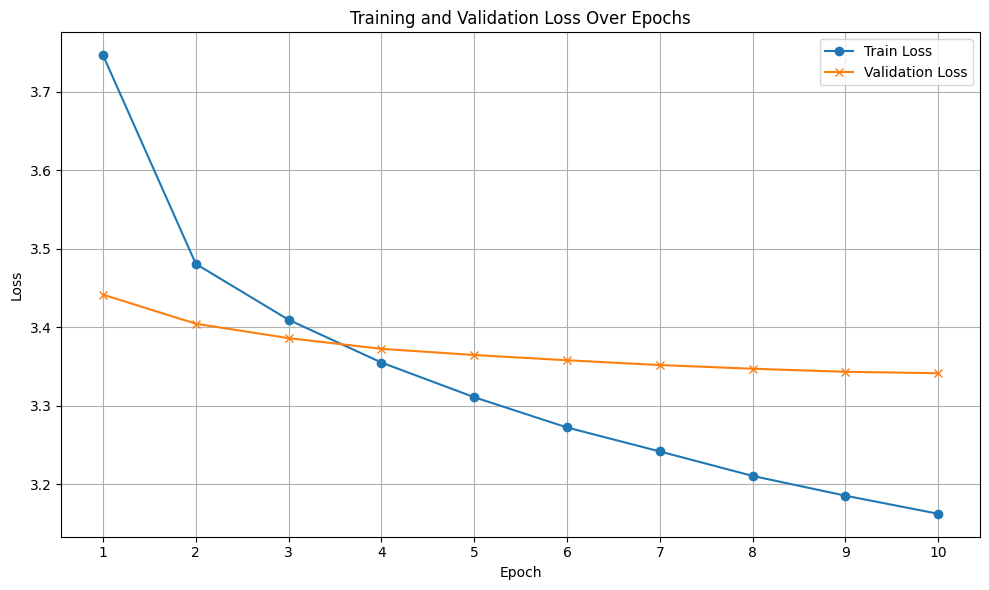

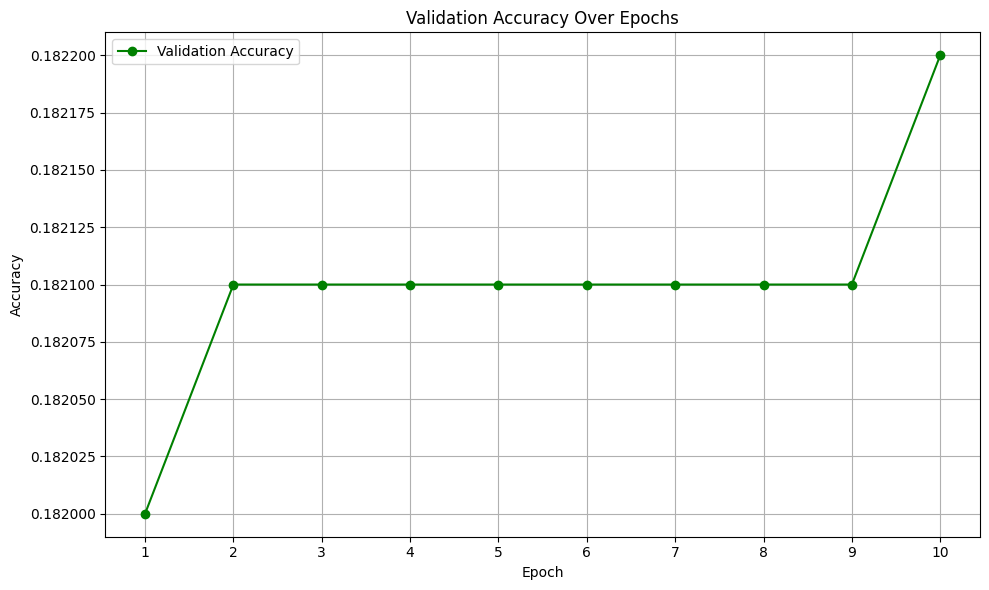

In [61]:

logs = """Epoch 1/10 | Train Loss: 3.7468 | Val Loss: 3.4415 | Val Acc: 0.1820
Epoch 2/10 | Train Loss: 3.4807 | Val Loss: 3.4044 | Val Acc: 0.1821
Epoch 3/10 | Train Loss: 3.4094 | Val Loss: 3.3860 | Val Acc: 0.1821
Epoch 4/10 | Train Loss: 3.3549 | Val Loss: 3.3724 | Val Acc: 0.1821
Epoch 5/10 | Train Loss: 3.3107 | Val Loss: 3.3645 | Val Acc: 0.1821
Epoch 6/10 | Train Loss: 3.2721 | Val Loss: 3.3578 | Val Acc: 0.1821
Epoch 7/10 | Train Loss: 3.2415 | Val Loss: 3.3517 | Val Acc: 0.1821
Epoch 8/10 | Train Loss: 3.2103 | Val Loss: 3.3470 | Val Acc: 0.1821
Epoch 9/10 | Train Loss: 3.1851 | Val Loss: 3.3431 | Val Acc: 0.1821
Epoch 10/10 | Train Loss: 3.1620 | Val Loss: 3.3413 | Val Acc: 0.1822"""

# Parsing the logs
epochs = []
train_losses = []
val_losses = []
val_accs = []

for line in logs.strip().split('\n'):

    if line.startswith('Epoch'):
        parts = line.split('|')
        epoch = int(parts[0].split(' ')[1].split('/')[0])
        train_loss = float(parts[1].split(':')[1].strip())
        val_loss = float(parts[2].split(':')[1].strip())
        val_acc = float(parts[3].split(':')[1].strip())

        epochs.append(epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

# Plotting Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.xticks(epochs)
plt.tight_layout()
plt.savefig('loss_curves.png')

# Plotting Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_accs, label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.xticks(epochs)
plt.tight_layout()
plt.savefig('val_accuracy_curve.png')

print("Loss curves and validation accuracy curve saved as PNG images.")
